# Ridge Regression

> Ridge Regularizatn
- It is a tehnique using which we induce some added info into ml model to reduce Overfitting

> 3 types of Regularizatn / Regression:
- Ridge(L2)
- Lasso (L1)
- Elastic Net (L1 + L2)

> Overfitting and Underfitting
- It can be seen in form of eqn of a line where m is slope and b is intercept
- So if m is too high or infinte -> y is highly dependent on m -> model will be overfit
- If m is too low or tends to 0 -> then y = b -> means no dependency on x -> model is underfit

# Ridge Regularizatn
- In this we need to reduce overfitting -> So we need to minimise the loss fn
- But here in this, we add a term in loss fn as
- L = (Yi - Y^i)^2 + lam(m^2)
- Here lambda is a Hyperparameter whose val can be changed(0 - infity)
<img src='img12.png'></img>

- Why L2 -> as it does m^2 so it called L2 norm

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
from sklearn.datasets import load_diabetes
data = load_diabetes()

In [9]:
x = data.data
y = data.target

In [12]:
from sklearn.model_selection import train_test_split
x_tr, x_ts, y_tr, y_ts = train_test_split(x,y, test_size=0.2, random_state=45)

In [14]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [15]:
lr.fit(x_tr, y_tr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
y_pred = lr.predict(x_ts)

In [17]:
from sklearn.metrics import r2_score, mean_squared_error

print(r2_score(y_ts, y_pred))
print(np.sqrt(mean_squared_error(y_ts, y_pred)))

0.5188113124539249
48.72713760953252


- Applying Ridge using lambda as alpha

In [18]:
from sklearn.linear_model import Ridge
R = Ridge(alpha=0.0001)

In [19]:
R.fit(x_tr, y_tr)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",Non

In [20]:
y_pred = R.predict(x_ts)

In [21]:
print(r2_score(y_ts, y_pred))
print(np.sqrt(mean_squared_error(y_ts, y_pred)))

0.518973263588495
48.718937001819555


- How underfitting and overfitting happen?

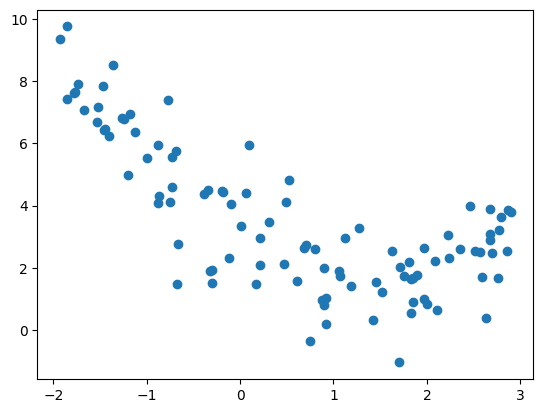

In [22]:
m = 100
x1 = 5 * np.random.rand(m,1) - 2
x2 = 0.7 * x1**2 - 2 * x1 + 3 + np.random.randn(m,1)

plt.scatter(x1,x2)
plt.show()

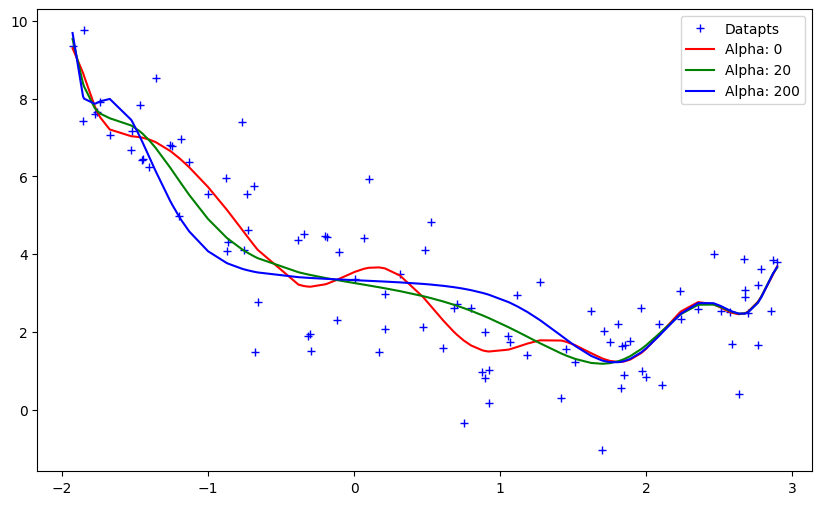

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1,x2,alpha):
    model = Pipeline([
        ("poly_feat", PolynomialFeatures(degree=16)),
        ("ridge", Ridge(alpha=alpha))
    ])
    model.fit(x1,x2)
    return model.predict(x1)

alphas = [0,20,200]
cs = ['r','g','b']

plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+',label='Datapts')

for alpha,c in zip(alphas,cs):
    preds = get_preds_ridge(x1,x2,alpha)
    # plot
    plt.plot(sorted(x1[:,0]), preds[np.argsort(x1[:,0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

> <h2>Mathematical Formulatn</h2>

<img src='img13.png'></img>
- For lam = 0, the m will be the same m as of SLR
- If change in m, then there will be change in b and that's how it is diff from SLR

- Applying Ridge

In [38]:
from sklearn.datasets import make_regression

In [39]:
x,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

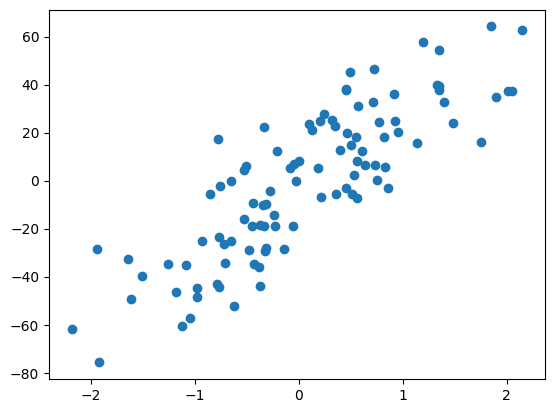

In [40]:
plt.scatter(x,y)

In [41]:
lr = LinearRegression()
lr.fit(x,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [42]:
rr = Ridge(alpha=10)
rr.fit(x,y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.1269130035235735


In [44]:
rr1 = Ridge(alpha=100)
rr1.fit(x,y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


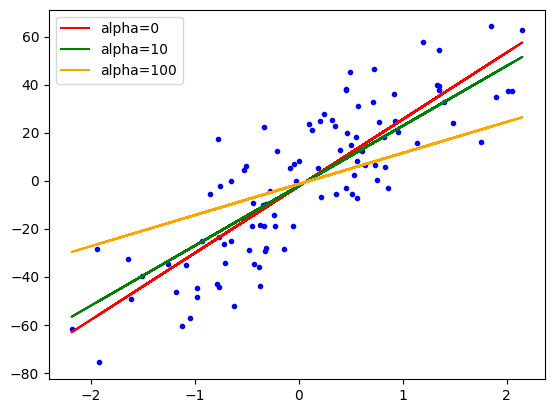

In [45]:
plt.plot(x,y,'b.')
plt.plot(x,lr.predict(x),color='red', label='alpha=0')
plt.plot(x,rr.predict(x),color='green', label='alpha=10')
plt.plot(x,rr1.predict(x),color='orange', label='alpha=100')
plt.legend()

> <h3>Making Code from scratch</h3>

In [46]:
class MeraRidge:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self, x_tr, y_tr):
        num = 0
        den = 0

        for i in range(x_tr.shape[0]):
            num = num + (y_tr[i] - y_tr.mean()) * (x_tr[i] - x_tr.mean())
            den = den + (x_tr[i] - x_tr.mean()) * (x_tr[i] - x_tr.mean())

        self.m = num / (den + self.alpha)
        self.b = y_tr.mean() - (self.m * x_tr.mean())
        print(self.m , self.b)

    def predict(x_ts):
        pass

In [51]:
reg = MeraRidge(100)

In [52]:
reg.fit(x,y)

[12.93442104] [-1.42484415]


> <h4>Applying ridge for N-Dim dataset</h4>
<img src='img15.png'></img>

- Using predefined fn

In [54]:
x,y = load_diabetes(return_X_y=True)

In [55]:
x_tr, x_ts, y_tr, y_ts = train_test_split(x,y,test_size=0.2, random_state=4)

In [56]:
reg = Ridge(alpha=0.1, solver='cholesky')

In [57]:
reg.fit(x_tr, y_tr)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'cholesky'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",No

In [58]:
y_pred = reg.predict(x_ts)
r2_score(y_ts, y_pred)

0.4693128853309805

In [59]:
print(reg.coef_)
print(reg.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


In [62]:
class MeraRidgeND:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self, x_tr, y_tr):

        x_tr = np.insert(x_tr, 0, 1, axis=1)
        I = np.identity(x_tr.shape[1])
        I[0][0] = 0 # to match sciit learn model
        result = np.linalg.inv(np.dot(x_tr.T, x_tr) + self.alpha * I).dot(x_tr.T).dot(y_tr)
        self.intercept_ = result[0]
        self.coef_ = result[1:]

    def predict(self, x_ts):
        return np.dot(x_ts, self.coef_) + self.intercept_

In [63]:
ri = MeraRidgeND()
ri.fit(x_tr, y_tr)
y_pred = ri.predict(x_ts)
print(r2_score(y_ts, y_pred))
print(ri.coef_)
print(ri.intercept_)

0.4693128853309806
[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.8905342560281


# Ridge using GD

In [1]:
class MeraRidgeGD:
    def __init__(self, epochs, learning_rate,alpha):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self, x_tr, y_tr):
        self.coef_ = np.ones(x_tr.shape[1])
        self.intercept_ = 0
        thetha = np.insert(self.coef_, 0, self.intercept_)

        x_tr = np.insert(x_tr, 0, 1, axis=1)

        for i in range(self.epochs):
            thetha_der = np.dot(x_tr.T, x_tr).dot(thetha) - np.dot(x_tr.T, y_tr) + self.alpha*thetha
            thetha = thetha - self.learning_rate*thetha_der

    def predict(self, x_ts):
        return np.dot(x_ts, self.coef_) + self.intercept_

> Ridge using Scikit learn built in class
- FOR GD : 3 solver -> sparse_cg, sag, saga
- FOR OLS : 3 solver -> svd, cholesky, lsqr

In [ ]:
# Ridge using Scikit GD
from sklearn.linear_model import Ridge
reg = Ridge(alpha=0.001, max_iter=500, solver='sparse_cg')

# 5 key Pts about Ridge Reg

> How coef get affected?
- lambda value varies from 0 to infinity
- So when lambda moves towards infinity or incs, the coeff dec and moves towards 0 but never become 0
- So when lambda inc, the val of coeff shrinks and get close to 0

> How much coeff val impacted?
- Higher val are more impacted than lower
- As higher the val, higher the shrinking
- So as labda inc, the higher coef val dec or shrinks more

> How Bias-Variance Tradeoff affected?
- If lambda inc -> Bias will dec -> Overfitting -> Variance inc
- If lambda dec -> Bias will inc -> Underfitting -> Variance dec

> Impact of lambda on the loss fn 
- So wehn lambda inc -> graph shrinks inward and moves towards origin

> Why called Ridge?
- As everytime the minima of loss fn to be made on this factor: L(B1^2 + B2^2) corcle ridge
- So that's why it is called ridge as shown in fig
<img src='img16.png'></img>

# Tip: When to apply
- When there are more than 2 input cols